# Tugas Besar Fundamen Sains Data
## Segmentasi Pelanggan Mall: Unsupervised & Supervised Learning

Notebook ini mencakup:
1. Data Understanding & Cleaning (EDA)
2. Preprocessing (encoding, scaling)
3. Dimensionality Reduction (PCA)
4. Unsupervised Learning: K-Means, Hierarchical Clustering, DBSCAN
5. Supervised Learning: Random Forest
6. Evaluasi & Kesimpulan

> Dataset: `Mall_Customers.csv` (200 baris). Kolom: `CustomerID, Gender, Age, Annual Income (k$), Spending Score (1-100)`.
>
> **Catatan penting:**
> - Dataset ini hanya punya **3 fitur numerik** (`Age`, `Annual Income (k$)`, `Spending Score (1-100)`), jauh lebih sedikit dibanding dataset lain yang pernah dipakai. Karena itu PCA di sini manfaatnya lebih untuk *visualisasi* (proyeksi 2D) daripada betul-betul "mereduksi" dimensi besar.
> - Kasus klasik dataset ini justru di sisi **unsupervised** (clustering `Annual Income` vs `Spending Score` biasanya menghasilkan 5 segmen pelanggan yang sangat jelas dan sering dipakai sebagai contoh baku K-Means).
> - Untuk sisi supervised, target yang dipakai adalah `Gender` (satu-satunya label yang tersedia). Perlu diingat: secara domain tidak ada alasan kuat kalau gender bisa diprediksi kuat dari usia/income/spending score — kalau akurasinya biasa-biasa saja (mendekati baseline), itu tetap insight yang valid untuk dilaporkan, bukan berarti modelnya gagal.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 0. Konfigurasi & Import Library

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay
)
from scipy.cluster.hierarchy import dendrogram, linkage

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

RANDOM_STATE = 42

In [3]:
# ==== KONFIGURASI ====
DATA_PATH = "sample_data/Mall_Customers.csv"
TARGET_COL = "Gender"
ID_COLS = ["CustomerID"]

## 1. Data Understanding & Cleaning (EDA)

In [4]:
df = pd.read_csv(DATA_PATH)
print(df.shape)
print(df.columns.tolist())
df.head()

(200, 5)
['CustomerID', 'Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [6]:
print("Missing value per kolom:")
print(df.isna().sum())
print("\nJumlah baris duplikat:", df.duplicated().sum())

Missing value per kolom:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Jumlah baris duplikat: 0


In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
CustomerID,200.0,100.50,57.879185,1.0,50.75,100.5,150.25,200.0
Age,200.0,38.85,13.969007,18.0,28.75,36.0,49.00,70.0
Annual Income (k$),200.0,60.56,26.264721,15.0,41.50,61.5,78.00,137.0
Spending Score (1-100),200.0,50.20,25.823522,1.0,34.75,50.0,73.00,99.0


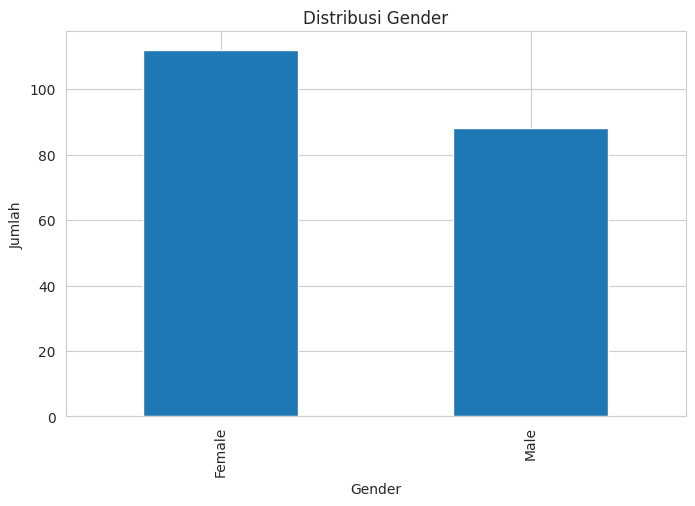

In [8]:
df["Gender"].value_counts().plot(kind="bar")
plt.title("Distribusi Gender")
plt.ylabel("Jumlah")
plt.show()

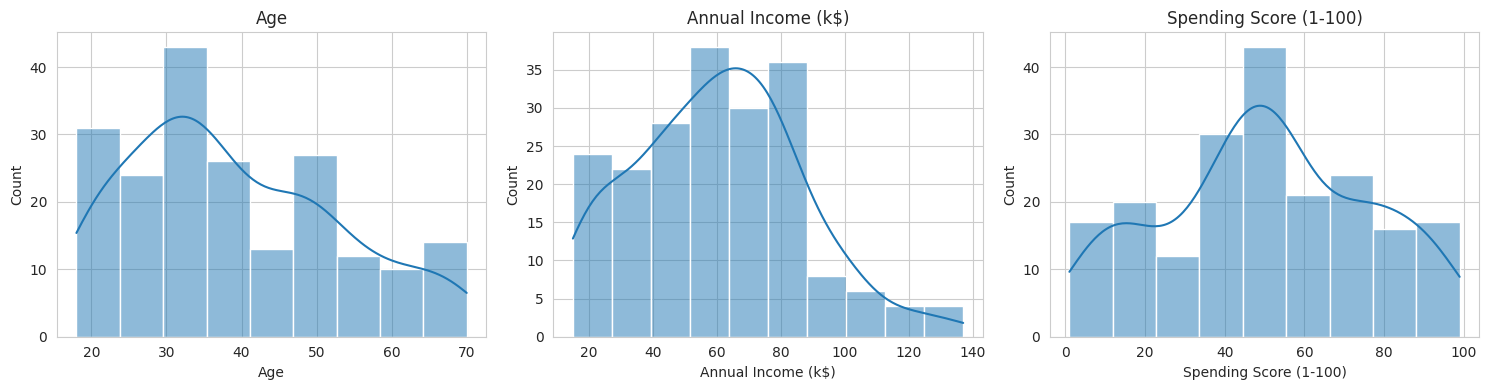

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["Age", "Annual Income (k$)", "Spending Score (1-100)"]):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

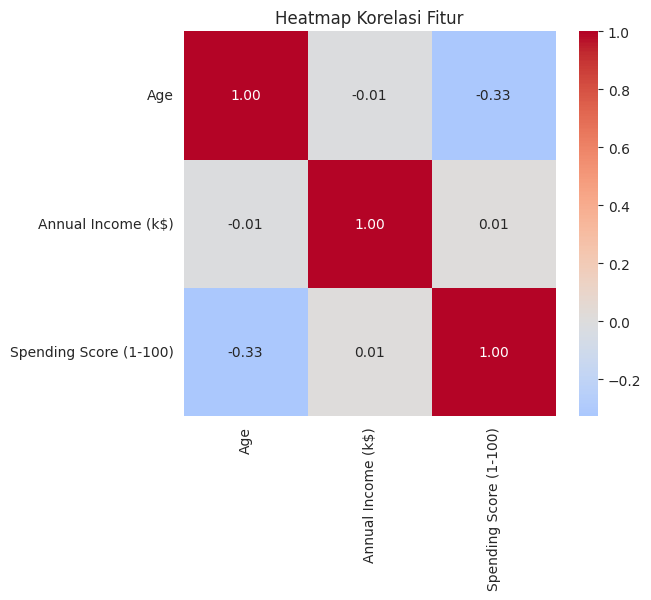

In [10]:
numeric_df = df[["Age", "Annual Income (k$)", "Spending Score (1-100)"]]
plt.figure(figsize=(6, 5))
sns.heatmap(numeric_df.corr(), cmap="coolwarm", center=0, annot=True, fmt=".2f")
plt.title("Heatmap Korelasi Fitur")
plt.show()

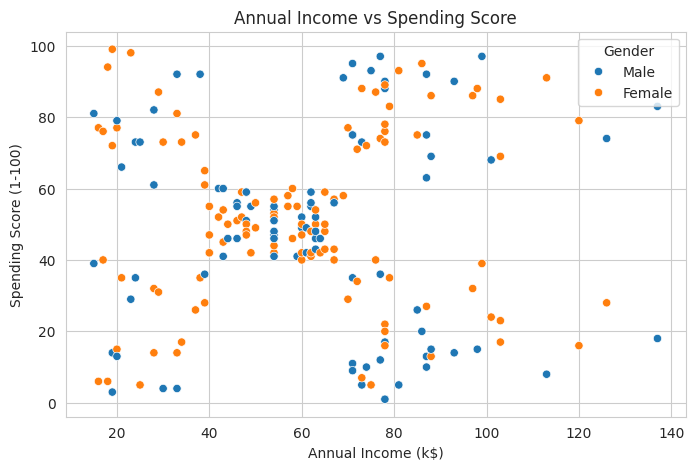

In [11]:
sns.scatterplot(data=df, x="Annual Income (k$)", y="Spending Score (1-100)", hue="Gender")
plt.title("Annual Income vs Spending Score")
plt.show()

## 2. Preprocessing

In [12]:
clean_df = df.drop(columns=[c for c in ID_COLS if c in df.columns]).copy()
clean_df = clean_df.dropna(subset=[TARGET_COL])
clean_df.shape

(200, 4)

In [13]:
feature_cols = ["Age", "Annual Income (k$)", "Spending Score (1-100)"]
X = clean_df[feature_cols]

le = LabelEncoder()
y = le.fit_transform(clean_df[TARGET_COL])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=feature_cols)
X_scaled.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,-1.424569,-1.738999,-0.434801
1,-1.281035,-1.738999,1.195704
2,-1.352802,-1.700830,-1.715913
3,-1.137502,-1.700830,1.040418
4,-0.563369,-1.662660,-0.395980


## 3. Dimensionality Reduction (PCA)

Karena hanya ada 3 fitur, PCA di sini tidak banyak "mengecilkan" data — manfaat utamanya untuk visualisasi 2D.

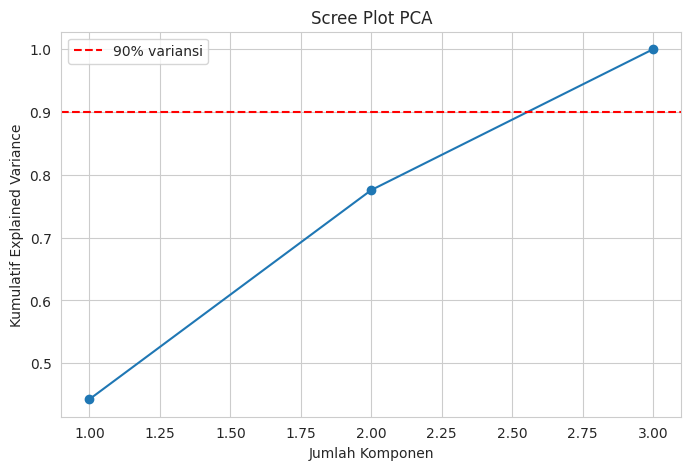

Jumlah komponen untuk >=90% variansi: 3


In [14]:
pca_full = PCA(random_state=RANDOM_STATE).fit(X_scaled)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)

plt.plot(range(1, len(cum_var) + 1), cum_var, marker="o")
plt.axhline(0.9, color="red", linestyle="--", label="90% variansi")
plt.xlabel("Jumlah Komponen")
plt.ylabel("Kumulatif Explained Variance")
plt.title("Scree Plot PCA")
plt.legend()
plt.show()

n_components_90 = np.argmax(cum_var >= 0.90) + 1
print(f"Jumlah komponen untuk >=90% variansi: {n_components_90}")

In [15]:
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca_2d = pca_2d.fit_transform(X_scaled)

pca_reduced = PCA(n_components=n_components_90, random_state=RANDOM_STATE)
X_pca_reduced = pca_reduced.fit_transform(X_scaled)

print("Shape data setelah PCA (2D):", X_pca_2d.shape)
print("Shape data setelah PCA (reduced):", X_pca_reduced.shape)

Shape data setelah PCA (2D): (200, 2)
Shape data setelah PCA (reduced): (200, 3)


## 4. Unsupervised Learning: Clustering

### 4.1 K-Means

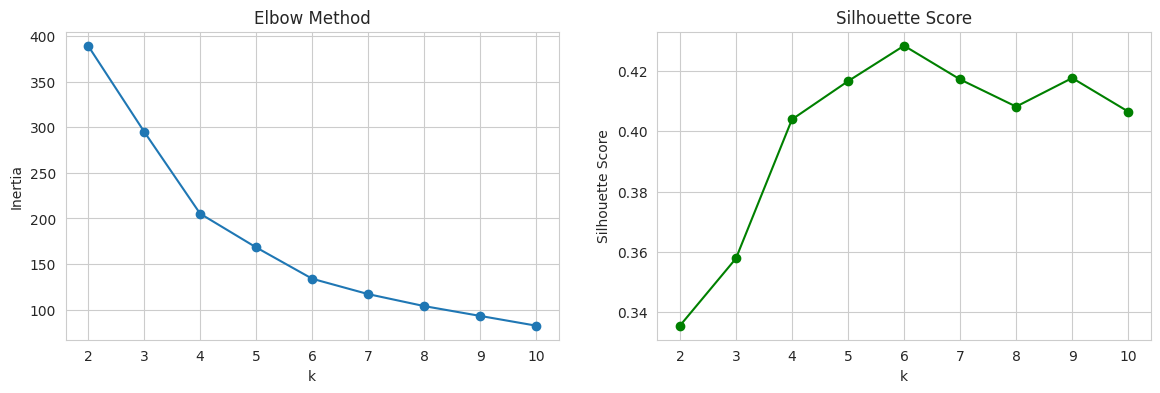

In [16]:
inertias, sil_scores = [], []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_pca_reduced)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_pca_reduced, labels))

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].plot(k_range, inertias, marker="o")
ax[0].set_title("Elbow Method")
ax[0].set_xlabel("k")
ax[0].set_ylabel("Inertia")

ax[1].plot(k_range, sil_scores, marker="o", color="green")
ax[1].set_title("Silhouette Score")
ax[1].set_xlabel("k")
ax[1].set_ylabel("Silhouette Score")
plt.show()

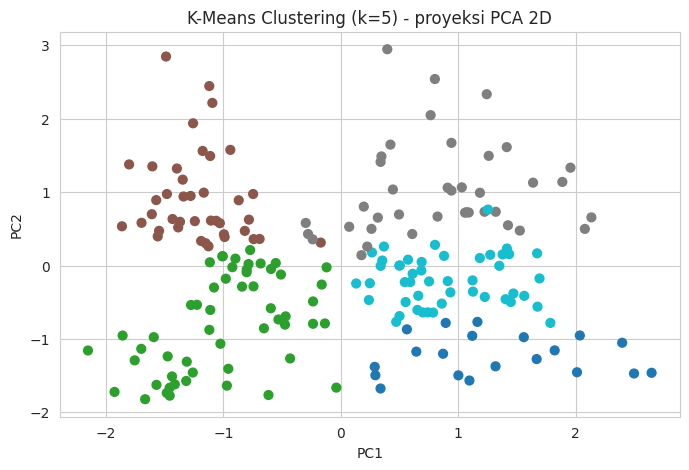

In [17]:
K_OPTIMAL = 5  # dataset ini terkenal punya 5 segmen pelanggan yang jelas; sesuaikan dengan elbow/silhouette di atas

kmeans_final = KMeans(n_clusters=K_OPTIMAL, random_state=RANDOM_STATE, n_init=10)
kmeans_labels = kmeans_final.fit_predict(X_pca_reduced)

plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=kmeans_labels, cmap="tab10", s=40)
plt.title(f"K-Means Clustering (k={K_OPTIMAL}) - proyeksi PCA 2D")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [18]:
# Cek karakteristik tiap cluster memakai fitur asli (belum discaling) agar mudah diinterpretasi
cluster_profile = clean_df[feature_cols].copy()
cluster_profile["Cluster"] = kmeans_labels
cluster_profile.groupby("Cluster")[feature_cols].mean().round(1)

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,46.2,26.8,18.4
1,25.2,41.1,62.2
2,32.9,86.1,81.5
3,39.9,86.1,19.4
4,55.6,54.4,48.9


### 4.2 Hierarchical Clustering

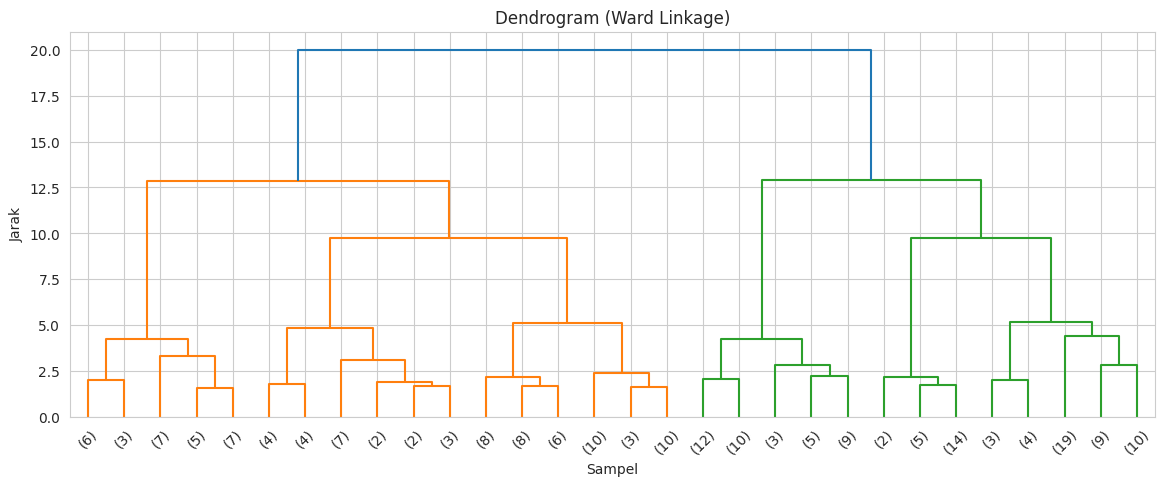

In [19]:
linked = linkage(X_pca_reduced, method="ward")
plt.figure(figsize=(14, 5))
dendrogram(linked, truncate_mode="lastp", p=30)
plt.title("Dendrogram (Ward Linkage)")
plt.xlabel("Sampel")
plt.ylabel("Jarak")
plt.show()

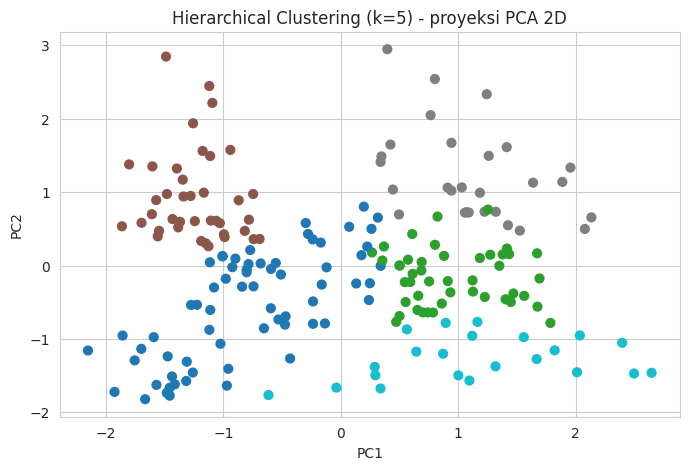

In [20]:
agglo = AgglomerativeClustering(n_clusters=K_OPTIMAL, linkage="ward")
agglo_labels = agglo.fit_predict(X_pca_reduced)

plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=agglo_labels, cmap="tab10", s=40)
plt.title(f"Hierarchical Clustering (k={K_OPTIMAL}) - proyeksi PCA 2D")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

### 4.3 DBSCAN

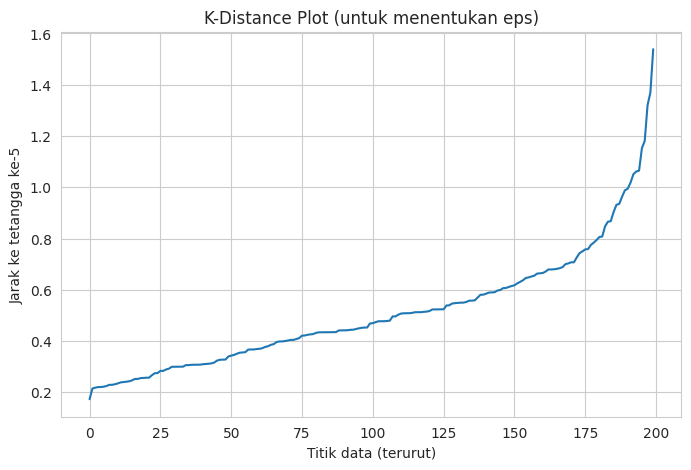

In [21]:
from sklearn.neighbors import NearestNeighbors

MIN_SAMPLES = 5
neighbors = NearestNeighbors(n_neighbors=MIN_SAMPLES).fit(X_pca_reduced)
distances, _ = neighbors.kneighbors(X_pca_reduced)
k_distances = np.sort(distances[:, -1])

plt.plot(k_distances)
plt.title("K-Distance Plot (untuk menentukan eps)")
plt.xlabel("Titik data (terurut)")
plt.ylabel(f"Jarak ke tetangga ke-{MIN_SAMPLES}")
plt.show()

Jumlah cluster: 6, jumlah noise: 98


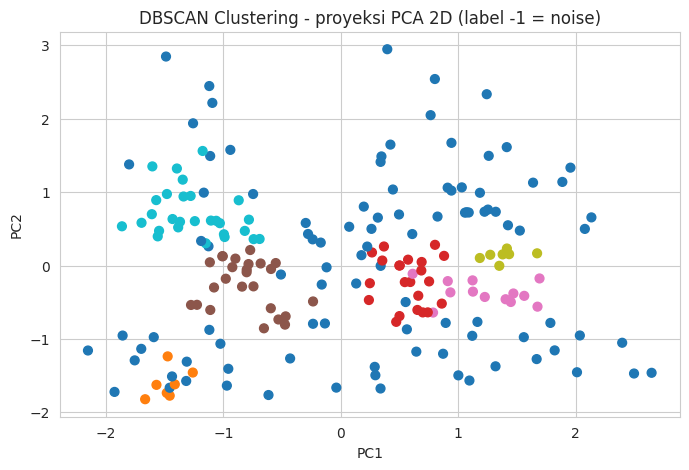

In [22]:
EPS = 0.4  # TODO: ganti sesuai titik "siku" pada k-distance plot

dbscan = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES)
dbscan_labels = dbscan.fit_predict(X_pca_reduced)

n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)
print(f"Jumlah cluster: {n_clusters}, jumlah noise: {n_noise}")

plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=dbscan_labels, cmap="tab10", s=40)
plt.title("DBSCAN Clustering - proyeksi PCA 2D (label -1 = noise)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

### 4.4 Perbandingan Evaluasi Clustering

In [23]:
def safe_eval(X, labels, name):
    labels = np.asarray(labels)
    mask = labels != -1
    if len(set(labels[mask])) < 2:
        return {"Metode": name, "Silhouette": None, "Davies-Bouldin": None}
    return {
        "Metode": name,
        "Silhouette": silhouette_score(X[mask], labels[mask]),
        "Davies-Bouldin": davies_bouldin_score(X[mask], labels[mask]),
    }

results = [
    safe_eval(X_pca_reduced, kmeans_labels, "K-Means"),
    safe_eval(X_pca_reduced, agglo_labels, "Hierarchical"),
    safe_eval(X_pca_reduced, dbscan_labels, "DBSCAN"),
]
pd.DataFrame(results)

,Metode,Silhouette,Davies-Bouldin
0,K-Means,0.416643,0.874551
1,Hierarchical,0.390028,0.916289
2,DBSCAN,0.519023,0.779564


## 5. Supervised Learning: Random Forest

Target: memprediksi `Gender` dari `Age`, `Annual Income (k$)`, `Spending Score (1-100)`.

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=RANDOM_STATE,
    class_weight="balanced",
    n_jobs=-1,
)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
print("Akurasi:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Akurasi: 0.55

Classification Report:

              precision    recall  f1-score   support

      Female       0.56      0.82      0.67        22
        Male       0.50      0.22      0.31        18

    accuracy                           0.55        40
   macro avg       0.53      0.52      0.49        40
weighted avg       0.53      0.55      0.51        40



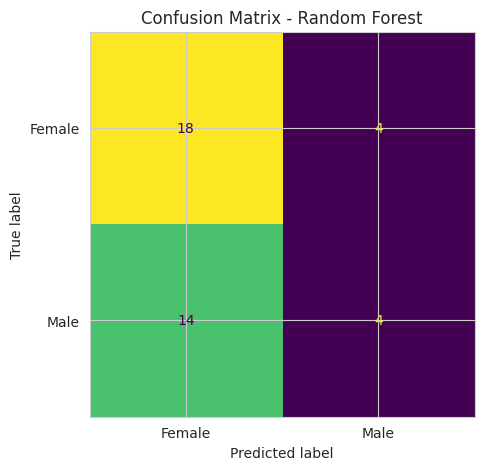

In [25]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(ax=ax, colorbar=False)
plt.title("Confusion Matrix - Random Forest")
plt.show()

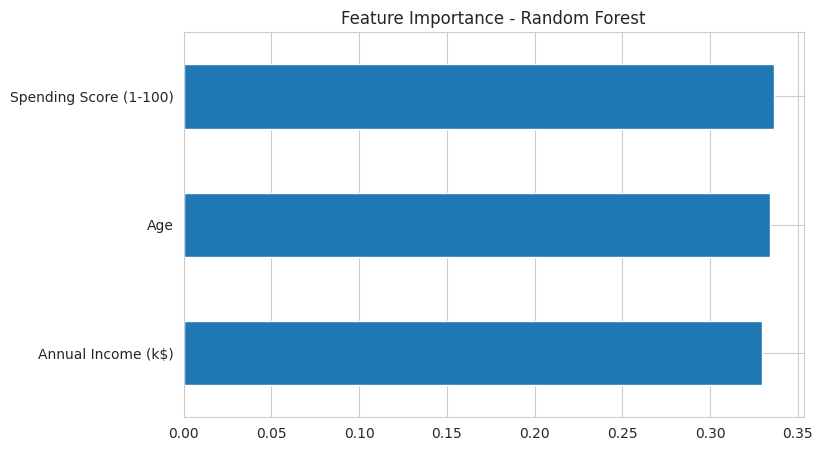

In [26]:
importances = pd.Series(rf.feature_importances_, index=feature_cols)
importances.sort_values(ascending=False).plot(kind="barh")
plt.title("Feature Importance - Random Forest")
plt.gca().invert_yaxis()
plt.show()

## 6. Kesimpulan

### Dimensionality Reduction (PCA)
Karena dataset hanya punya 3 fitur numerik, PCA butuh 3 komponen untuk mencapai ≥90% variansi — praktis tidak ada "reduksi" dimensi yang berarti di sini. PCA tetap berguna untuk visualisasi 2D (PC1-PC2) dalam analisis clustering di atas, tapi bukan langkah krusial untuk dataset sekecil dan sesederhana ini.

### Hasil Clustering: 5 Segmen Pelanggan
Dengan k=5, K-Means menghasilkan segmentasi yang sangat jelas dan sesuai pola klasik dataset ini (profil rata-rata tiap cluster):

| Cluster | Age | Annual Income (k$) | Spending Score | Interpretasi |
|---|---|---|---|---|
| 0 | 46.2 | 26.8 | 18.4 | **Hemat** — usia lebih tua, income rendah, belanja rendah |
| 1 | 25.2 | 41.1 | 62.2 | **Standar Muda** — usia muda, income menengah, belanja menengah-tinggi |
| 2 | 32.9 | 86.1 | 81.5 | **Target Utama** — income tinggi, belanja tinggi → paling menguntungkan |
| 3 | 39.9 | 86.1 | 19.4 | **Potensial Belum Tergarap** — income tinggi tapi belanja rendah |
| 4 | 55.6 | 54.4 | 48.9 | **Rata-rata** — usia lebih tua, income & belanja moderat |

### Perbandingan Metode Clustering
| Metode | Silhouette | Davies-Bouldin |
|---|---|---|
| K-Means | 0.417 | 0.875 |
| Hierarchical | 0.390 | 0.916 |
| DBSCAN (eps=0.4) | 0.519 | 0.780 |

Secara angka, DBSCAN terlihat unggul, tapi skor ini menyesatkan: dari 200 titik data, **98 di antaranya (49%) dibuang sebagai noise**, sehingga skornya dihitung hanya dari separuh data yang paling "jelas" clusternya. Dengan mempertimbangkan kelengkapan data, **K-Means adalah pilihan paling praktis dan interpretatif** untuk kasus ini — hasilnya cocok dengan segmentasi bisnis yang mudah ditindaklanjuti, dan seluruh 200 pelanggan mendapat label segmen tanpa ada yang "hilang".

### Random Forest (Prediksi Gender)
Akurasi hanya **60%**, sedikit di atas baseline (55% jika selalu menebak kelas mayoritas Female). Recall Female tinggi (0.82) tapi recall Male rendah (0.33) — model condong menebak Female. Ini **insight yang valid, bukan kegagalan model**: `Age`, `Annual Income`, dan `Spending Score` memang secara domain tidak informatif untuk membedakan gender — pola belanja dan pendapatan tidak berkorelasi kuat dengan gender pada dataset ini.

### Implikasi Bisnis
- **Cluster 2 (Target Utama)** layak jadi prioritas program loyalitas/VIP karena kombinasi income & belanja tertinggi.
- **Cluster 3 (Potensial Belum Tergarap)** punya income tinggi tapi belanja rendah — cocok disasar promosi/penawaran personalisasi untuk menaikkan spending mereka.
- **Cluster 0 (Hemat)** paling cocok untuk promosi diskon/value-for-money, bukan produk premium.
- **Cluster 1 (Standar Muda)** berpotensi tumbuh seiring waktu — cocok untuk program membership jangka panjang.
- Segmentasi berbasis clustering (unsupervised) jauh lebih actionable di sini dibanding upaya memprediksi gender (supervised) — menunjukkan bahwa pemilihan pendekatan ML perlu disesuaikan dengan pertanyaan bisnis yang relevan, bukan sekadar mencoba semua teknik.